In [38]:
import os, re, sys, json, time, ast, operator, subprocess
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

# ------------------------------------------------------------------
# Раньше был ОДИН CHAT_URL (OpenRouter), сейчас по одному URL на КАЖДЫЙ
# уровень модели, т.к. это разные локальные серверы на разных портах.
# ------------------------------------------------------------------
MODELS = {
    "cheap":  "http://localhost:8080/v1/chat/completions",
    "mid":    "http://localhost:8002/v1/chat/completions",
    "strong": "http://localhost:8003/v1/chat/completions",
}

# HEADERS больше не нужен Authorization/Referer/Title - это было специфично для OpenRouter (идентификация приложения). 
# llama-server по умолчанию запросы не авторизует. 
HEADERS = {"Content-Type": "application/json"}

COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}

DATA = next((p for p in [Path("qa_data"), Path("/kaggle/input/datasets/artmakar04/"), Path("/kaggle/input/seminar01-data/data")]
             if (p / "compare_10.jsonl").exists()), Path("qa-data"))




In [2]:
@dataclass
class Ledger:
    calls: list = field(default_factory=list)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        # У локального сервера поля "cost" в usage нет.
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model, "prompt": p, "completion": c,
                           "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    def table(self):
        df = pd.DataFrame(self.calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)


ledger = Ledger()



In [3]:

def post_with_retry(url, body, attempts=3):
    """
    url теперь параметр функции, а не глобальная константа, т.к. у каждой модели свой адрес.
    """
    for attempt in range(attempts):
        r = requests.post(url, json=body, headers=HEADERS, timeout=120)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (429, 500, 502, 503) and attempt < attempts - 1:
            time.sleep(1.5 * (attempt + 1))
            continue
        raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")

In [ ]:
def chat(messages, model, tools=None, tag="chat", temperature=None):
    """
    Главное отличие от оригинала: раньше параметром был "model" (строка вроде "anthropic/claude-sonnet-4.6"),
    теперь это "tier" — ключ словаря MODELS ("cheap"/"mid"/"strong"), по которому определяется, на какой порт стучаться.

    Поле "model" в теле запроса при этом всё равно нужно передать:
    llama-server его ожидает по спецификации OpenAI API, но реально
    игнорирует, если сервер поднят с одной-единственной моделью
    (она уже зафиксирована в самом процессе сервера через -m).
    """
    if model not in MODELS:
        raise ValueError(f"Неизвестный уровень модели: {model}. Доступно: {list(MODELS)}")

    url = MODELS[model]
    body = {"model": model, "messages": messages}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature

    started = time.perf_counter()
    data = post_with_retry(url, body)
    # В ledger теперь пишем "tier" вместо распарсенного имени модели
    # (в оригинале было model.split("/")[-1] — там резали префикс
    # провайдера вроде "anthropic/"; здесь такого префикса просто нет).
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]


In [6]:
msg = chat(
    messages=[{"role": "user", "content": "Сложи 2 и 2"}],
    model="cheap",       # вместо MODELS["cheap"] сразу строки с именем
    tag="arithmetic",
)
print(msg["content"])
print(ledger.table())

2 + 2 = 4
                  calls  prompt  completion  cost  seconds
tag        model                                          
arithmetic cheap      1      23         170   0.0     5.24


In [7]:
class Answer(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ: число или короткая фраза")

SCHEMA_PROMPT = "Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{schema}"

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        raise ValueError("в ответе нет JSON")
    return json.loads(m.group(0), strict=False)

In [8]:
Answer.model_json_schema()

{'properties': {'reasoning': {'description': 'ход решения в два-три предложения',
   'title': 'Reasoning',
   'type': 'string'},
  'final': {'description': 'только итоговый ответ: число или короткая фраза',
   'title': 'Final',
   'type': 'string'}},
 'required': ['reasoning', 'final'],
 'title': 'Answer',
 'type': 'object'}

In [9]:
schema=Answer
SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))

'Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{"properties": {"reasoning": {"description": "ход решения в два-три предложения", "title": "Reasoning", "type": "string"}, "final": {"description": "только итоговый ответ: число или короткая фраза", "title": "Final", "type": "string"}}, "required": ["reasoning", "final"], "title": "Answer", "type": "object"}'

In [10]:
def ask_structured(question, model, schema=Answer, attempts=3):
    messages = [
        {"role": "system", "content": SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))},
        {"role": "user", "content": question}
    ]
    for _ in range(attempts):
        msg = chat(messages, model, tag="struct")
        try:
            return schema.model_validate(json_from(msg["content"]))
        except (ValidationError, ValueError) as e:
            messages += [msg, {"role": "user", "content": f"Ответ не прошел проверку на структуру: {e}. Верни ответ по строгой JSON схеме"}]
    raise ValueError("Модель не справилась")


In [16]:
def load_tasks(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

task = "What was the name of the hurricane that brought heavy rainfall to Hawaii in August 2026?"
ans = ask_structured(task, "cheap")
ans.final

'Hurricane Hina (projected)'

In [20]:
class Numeric(BaseModel):
    final: float = Field(description="ответ числом")

calls_before = len(ledger.calls)
try:
    result = ask_structured("Какой год основания франции", "cheap", Numeric)
except ValueError as e:
    result = e
print("вызовов потрачено:", len(ledger.calls) - calls_before, "| результат:", result)

вызовов потрачено: 1 | результат: final=44.0


In [22]:
prompt = [{"role": "user", "content": "Придумай название для кофейни рядом с университетом. Один ответ: Только название, два слова."}]
pd.DataFrame({f"temperature {t}": [chat(prompt, "cheap", tag="temperature", temperature=t)["content"] for _ in range(5)]
              for t in (0.0, 1.2)})

,temperature 0.0,temperature 1.2
0,Студенческий Кофе,Университетский Кофе
1,Студенческий Кофе,Студенческий Кофе
2,Студенческий Кофе,Университетский кофе
3,Студенческий Кофе,Пауза Знаний
4,Студенческий Кофе,Университетский кофе.


In [ ]:
def normalize(text):
    text = re.sub(r"[^\w\s]", " ", str(text).lower().replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def is_correct(task, answer):
    if task["source"] == "gsm8k":
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(answer).replace(",", ""))
        return bool(nums) and abs(float(nums[-1]) - float(task["answer"])) < 1e-6
    return normalize(task["answer"]) in normalize(answer)

def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

def compare_models(tasks, models):
    rows = []
    for name, model in models.items():
        before, correct, started = ledger.total, 0, time.perf_counter()
        for task in tasks:
            try:
                correct += is_correct(task, ask_structured(task["question"], model).final)
            except Exception:
                pass
        rows.append(summary("без инструментов, JSON", model, len(tasks), correct, ledger.total - before, 1,
                            (time.perf_counter() - started) / len(tasks)))
    return pd.DataFrame(rows)

def compare_chart(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].bar(df["model"], df["accuracy"] * 100, color=COLORS["violet"])
    axes[0].set_ylabel("доля верных, %")
    axes[0].set_ylim(0, 105)
    axes[1].bar(df["model"], df["cost_per_correct"] * 100, color=COLORS["amber"])
    axes[1].set_ylabel("цена верного ответа, центы")
    axes[2].bar(df["model"], df["avg_seconds"], color=COLORS["teal"])
    axes[2].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.tick_params(axis="x", labelrotation=12)
        ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    return fig

In [23]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("допустимы только числа и арифметика")

class CalcArgs(BaseModel):
    expr: str = Field(description="арифметическое выражение, например 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

register(calculator, CalcArgs, "Считает арифметическое выражение: числа, скобки, + - * / ** %")
json.dumps(TOOLS["calculator"]["schema"], ensure_ascii=False, indent=1)

'{\n "type": "function",\n "function": {\n  "name": "calculator",\n  "description": "Считает арифметическое выражение: числа, скобки, + - * / ** %",\n  "parameters": {\n   "properties": {\n    "expr": {\n     "description": "арифметическое выражение, например 17*23+5",\n     "title": "Expr",\n     "type": "string"\n    }\n   },\n   "required": [\n    "expr"\n   ],\n   "title": "CalcArgs",\n   "type": "object"\n  }\n }\n}'

In [24]:
SYSTEM = ("Ты решаешь задачи. Если нужно посчитать или найти факт, вызывай инструменты, а не угадывай. "
          "Когда ответ готов, напиши его последней строкой в формате FINAL: <ответ>. "
          "Для числовых задач в FINAL только число, для вопросов о фактах короткая фраза.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

In [25]:
def run_tool(call):
    name = call["function"]["name"]

    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id" : call["id"], "content": str(result)[:2000]}

In [26]:
def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []

        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)

        messages += [run_tool(c) for c in calls]

In [47]:
def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:320]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [28]:
run = agent("Сколько будет 17 * 23 + 5? Посчитай инструментом.", "cheap", ["calculator"])
show_trace(run)

user     | Сколько будет 17 * 23 + 5? Посчитай инструментом. 
assistant|  calculator{"expr":"17 * 23 + 5"}
tool     | 396 
assistant| FINAL: 396 
шагов: 2, цена: 0.000 ¢, время: 5.4 c


In [30]:
run = agent("Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа.", "cheap", ["calculator"])
show_trace(run)
[len(m.get("tool_calls") or []) for m in run.messages if m["role"] == "assistant"]

user     | Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа. 
assistant|  calculator{"expr":"3.14159 * 3^2"}
tool     | ошибка вычисления: допустимы только числа и арифметика 
assistant|  calculator{"expr":"3.14159 * 3 * 3"}
tool     | 28.2743 
assistant|  calculator{"expr":"4^3"}
tool     | ошибка вычисления: допустимы только числа и арифметика 
assistant|  calculator{"expr":"4 * 4 * 4"}
tool     | 64 
assistant| Площадь круга: 28.2743 Объём куба: 64 FINAL: 28.2743 и 64 
шагов: 5, цена: 0.000 ¢, время: 14.3 c


[1, 1, 1, 1, 0]

In [34]:
class BrokenArgs(BaseModel):
    query: str = Field(description="любой запрос")

def broken_search(query: str) -> str:
    return "ошибка: сервис недоступен, попробуйте ещё раз"

register(broken_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")
run = agent("Кто написал роман «Мы»? Обязательно проверь через broken_search.", "cheap", ["broken_search"], max_steps=2)
show_trace(run)

user     | Кто написал роман «Мы»? Обязательно проверь через broken_search. 
assistant|  broken_search{"query":"кто написал роман \"Мы\""}
tool     | ошибка: сервис недоступен, попробуйте ещё раз 
user     | Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>. 
assistant| Роман «Мы» был написан советским писателем и философом Евгением Замятиным. FINAL: Евгений Замятин 
шагов: 3, цена: 0.000 ¢, время: 8.8 c


In [36]:
def flaky_search(query: str) -> str:
    return "ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова"

register(flaky_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")
run_flaky = agent("Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат.", "cheap", ["flaky_search"], max_steps=4)
show_trace(run_flaky)

user     | Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат. 
assistant|  flaky_search{"query":"автор романа Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"кто написал роман Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"автор романа \"Мы\""}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
user     | Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>. 
assistant| Роман «Мы» написан советским писателем и мыслителем Евгением Замятиным. FINAL: Евгений Замятин 
шагов: 5, цена: 0.000 ¢, время: 14.9 c


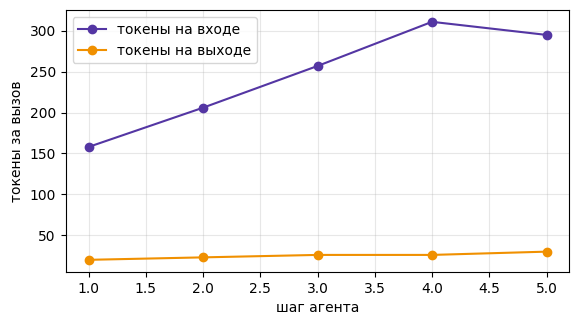

In [39]:
def context_chart(run):
    calls = [c for c in ledger.calls if c["tag"] == "agent"][-run.steps:]
    steps = range(1, len(calls) + 1)
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.plot(steps, [c["prompt"] for c in calls], marker="o", color=COLORS["violet"], label="токены на входе")
    ax.plot(steps, [c["completion"] for c in calls], marker="o", color=COLORS["amber"], label="токены на выходе")
    ax.set_xlabel("шаг агента")
    ax.set_ylabel("токены за вызов")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

context_chart(run_flaky);

In [40]:
WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "agents-course-seminar01/1.0 (https://postypashki.ru; educational project)"}

def wiki(params, attempts=3):
    for attempt in range(attempts):
        r = requests.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=15)
        if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
            return r.json()["query"]
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"Википедия ответила {r.status_code}")

class SearchArgs(BaseModel):
    query: str = Field(description="короткий поисковый запрос: имя, название, термин")

class ExecArgs(BaseModel):
    code: str = Field(description="код на Python; результат надо напечатать через print")

In [41]:
def web_search(query: str) -> str:
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})["search"]

    if not hits:
        return "No data"
    pages = wiki({"action":"query", "prop": "extracts", "explainttext": 1, "exinro": 1, "titles": hits[0]["title"]})["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())
    return f"[{hits[0]["title"]}] {text[:5000]}"

In [42]:
def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "Код исполнился но результат пустой"

In [43]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(python_exec, ExecArgs, "Выполняет код на Python в отдельном процессе и возвращает то, что он напечатал")

assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert "ошибка" in calculator("__import__('os')")
assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
assert web_search("qwxzv 1234567 nonsense") == "No data"
assert python_exec("print(sum(range(10)))") == "45"
assert "ZeroDivisionError" in python_exec("1/0")
assert "Код превысил 5 сек" in python_exec("import time; time.sleep(10)")
"инструменты работают"

'инструменты работают'

In [44]:
run = agent("Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате.", "cheap", ["python_exec"])
show_trace(run)

user     | Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате. 
assistant|  python_exec{"code":"from datetime import date\n\ntoday = date.today()\nnew_year = date(today.year + 1, 1, 1)\ndays_left = (new_year - today).days\n\nprint(f\"Today: {today}\")\nprint(f\"New Year: {new_year}\")\nprint(f\"Days left: {days_left}\")\n"}
tool     | Today: 2026-09-20 New Year: 2027-01-01 Days left: 103 
assistant| До Нового года осталось 103 дня. FINAL: 103 
шагов: 2, цена: 0.000 ¢, время: 7.1 c


user     | кто выиграл женский US Open 2026 по теннису. Использовать поиск 
assistant|  web_search{"query":"2026 US Open women's singles winner"}
tool     | [2026 US Open (tennis)] <p class="mw-empty-elt"> </p> <p>The <b>2026 US Open</b> was the 146th edition of tennis' US Open, and the fourth and final Grand Slam event of the year. It was held on the outdoor hard courts at the USTA Billie Jean King National Tennis Center in New York City. Carlos Alcaraz and Aryna Sabalenk 
assistant| На данный момент женский турнир US Open 2026 еще не состоялся (он пройдет в авгуске-сентябре 2026 года). Однако, согласно предварительным данным (или если рассматривать текущий прогноз), победительницей еще не определена. Если же опираться на текущие данные из поиска, турнир еще впереди. Если в вашем вопросе подразумев 
шагов: 2, цена: 0.000 ¢, время: 12.6 c


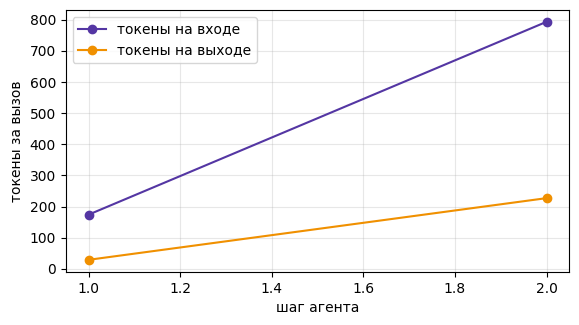

In [48]:
run = agent("кто выиграл женский US Open 2026 по теннису. Использовать поиск", "cheap", ["web_search"])
show_trace(run)
context_chart(run);